# Self-organising map of adolescent mental health
Maria B. Jelen

This script:
1) Imports symptom data for the sample
2) Trains a Self-Organising Map (SOM) using parameters obtained through parameter search
3) Interprets SOM topology using clusters and psychopathology profiles
4) Uses classification to validate psychopathology profiles on SOM topology
5) Triangulates symptom-based topology with KSADS-based current diagnostic burden
6) Obtains profile centroids and profile membership assignment for next analyses

In [1]:
# Load packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom 

In [2]:
# Plotting params
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal"
})

In [3]:
# Set working dir to the location of the notebook

import os
from pathlib import Path

notebook_dir = Path().resolve()
os.chdir(notebook_dir)

# Double-check dir
print("Working directory set to:", os.getcwd())

Working directory set to: \\cbsu\data\Imaging\projects\external\abcd\analyses\Maria\ABCD_MH\demo


----

## Training SOM

### Setting up the data

In [4]:
# Load CSV file
mock_baseline = pd.read_csv("mock_baseline.csv")
print(mock_baseline.shape) # expected (200,10)

(200, 11)


In [5]:
# Select feature columns
features = ['cbcl_scr_syn_anxdep_r', 'cbcl_scr_syn_withdep_r', 'cbcl_scr_syn_somatic_r', 'cbcl_scr_syn_social_r', 'cbcl_scr_syn_thought_r', 'cbcl_scr_syn_attention_r', 'cbcl_scr_syn_rulebreak_r', 'cbcl_scr_syn_aggressive_r', 'sds_p_ss_dims_final', 'Mania_Total'] 
data_for_som = mock_baseline[features].dropna().to_numpy()

# Scale values to range [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
data_for_som = scaler.fit_transform(data_for_som)

# Calculate SOM size
n_samples = data_for_som.shape[0]
map_size = int(5 * np.sqrt(n_samples))

# Make it a square grid 
size = int(np.ceil(np.sqrt(map_size)))
print(f"SOM size: {size}x{size}")
print(f"Data shape: {data_for_som.shape}")
print(f"First 10 rows:\n{data_for_som[:10]}")

SOM size: 9x9
Data shape: (200, 10)
First 10 rows:
[[-0.94368404 -0.62897254 -0.81507416 -0.98981403 -0.65391128 -0.79537754
  -0.86563797 -0.56933139 -0.65690744 -0.62313689]
 [-0.79352688 -0.76130284 -0.79952392 -0.63350376 -0.95133909 -0.55968241
  -0.82364775 -0.7401684  -0.97061694 -0.59444502]
 [-0.76861065 -0.95411697 -0.86815255 -0.4379137  -0.62704114 -0.82039027
  -0.03842547 -0.12196808 -0.66052884 -0.36917482]
 [-0.52981057 -0.84256849 -0.89096462  0.3675214  -0.72688343 -0.794572
  -0.42894976 -0.56736451  0.76624251 -0.40546134]
 [-0.53746952 -0.77934683 -0.62733301 -0.4208804  -0.98200462 -0.98981453
  -0.98892208 -0.73677832 -0.91087083 -0.5034984 ]
 [-0.9870077  -0.20654028 -0.98882716 -0.93182927 -0.91756483 -0.77078389
  -0.19206793 -0.86253093 -0.15100219 -0.75319148]
 [-0.40783433 -0.82270634 -0.704071   -0.82730482 -0.886122   -0.39886352
  -0.8119955  -0.97989989 -0.93064475 -0.60433874]
 [-0.99099358 -0.66967071 -0.43843013 -0.68738056 -0.78965265 -0.80987692
  

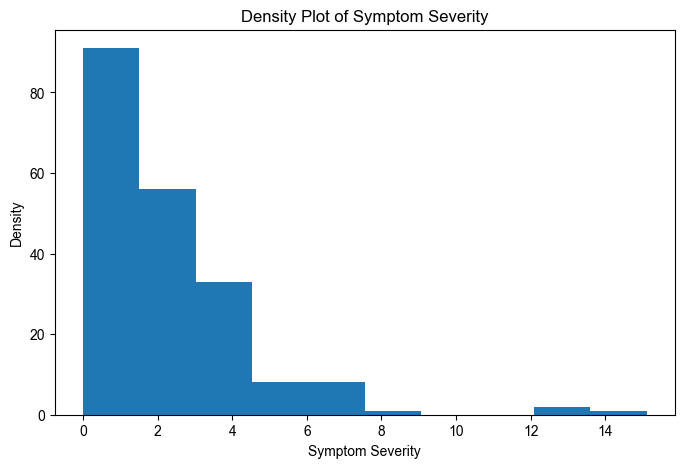

In [6]:
# Replace with column name to view
symptoms = mock_baseline["cbcl_scr_syn_anxdep_r"]

# Create density plot
plt.figure(figsize=(8, 5))
symptoms.plot(kind="hist")

# Labels and title
plt.xlabel("Symptom Severity")
plt.ylabel("Density")
plt.title("Density Plot of Symptom Severity")

plt.show()

### Parameter search

Training multiple SOMs with varying learning rate and sigma parameters to find optimal solution with lowest combination of quantization and topographic error 

In [7]:
grid_rows = 24
grid_cols = 24
learning_rates = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7]  # loop over these values
iterations = 500
sigma_values = [0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7]  # loop over sigmas

results = {}

for sigma in sigma_values:
    for rate in learning_rates:
        print(f"Training SOM with sigma: {sigma} and rate: {rate}")
        # Initialize the SOM
        som = MiniSom(grid_rows, grid_cols, 10, sigma=sigma, learning_rate=rate)

        # Initialize weights randomly
        som.random_weights_init(data_for_som)

        # Train the SOM
        som.train_random(data_for_som, iterations, verbose=True)

        # Evaluate the SOM
        quant_error = som.quantization_error(data_for_som)
        topo_error = som.topographic_error(data_for_som)
        umat = som.distance_map().T
        activation_map = som._activation_map

        # Tuple of sigma and learning rate
        results[(sigma, rate)] = {'quant_error': quant_error, 'topo_error': topo_error, 'umat': umat, 'weights': som.get_weights()}

        print(f"Quantization error for sigma={sigma}, rate={rate}: {quant_error}")
        print(f"Topographic error for sigma={sigma}, rate={rate}: {topo_error}\n")

Training SOM with sigma: 0.7 and rate: 0.1
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.03154335659150332
Quantization error for sigma=0.7, rate=0.1: 0.03154335659150332
Topographic error for sigma=0.7, rate=0.1: 0.985

Training SOM with sigma: 0.7 and rate: 0.15
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.04209069164868735
Quantization error for sigma=0.7, rate=0.15: 0.04209069164868735
Topographic error for sigma=0.7, rate=0.15: 0.99

Training SOM with sigma: 0.7 and rate: 0.2
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.04135750895532262
Quantization error for sigma=0.7, rate=0.2: 0.04135750895532262
Topographic error for sigma=0.7, rate=0.2: 0.97

Training SOM with sigma: 0.7 and rate: 0.25
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.055706929488509596
Quantization error for sigma=0.7, rate=0.25: 0.055706929488509596
Topographic error for sigma=0.7, rate=0.25: 0.985

Training SOM with sigma: 0.7 and rate: 0.3
 [ 500 / 500 ] 

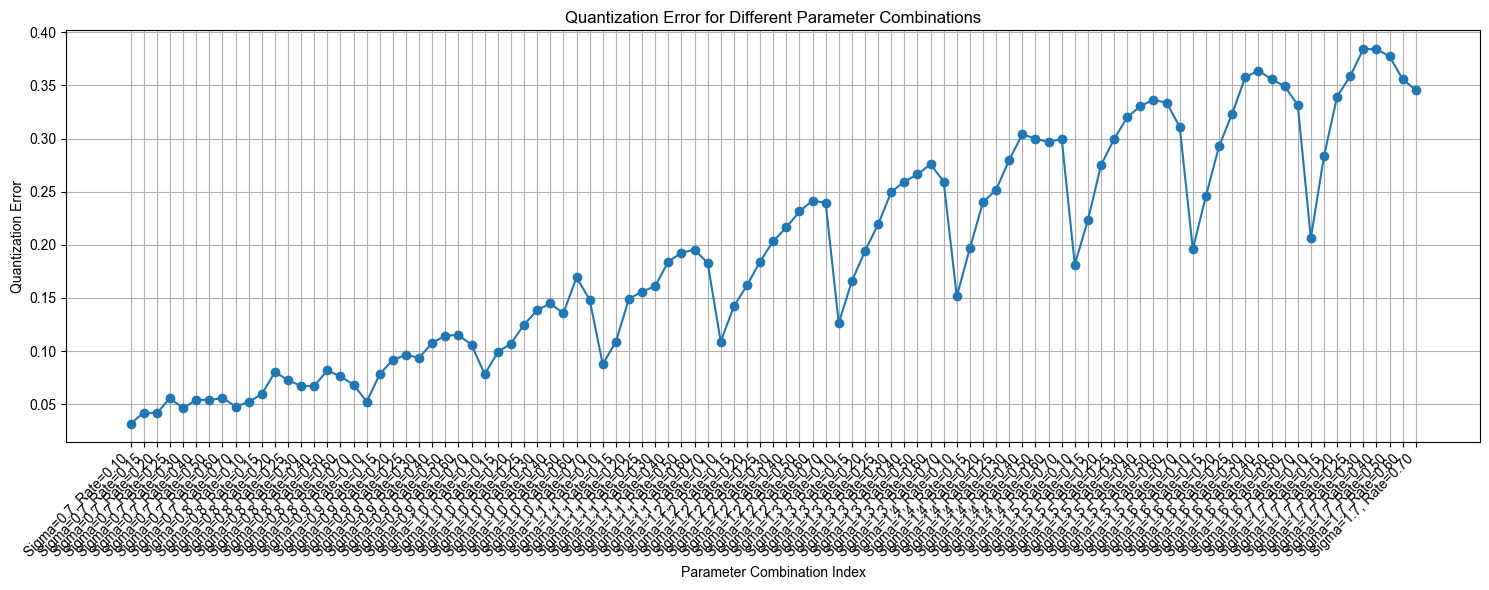

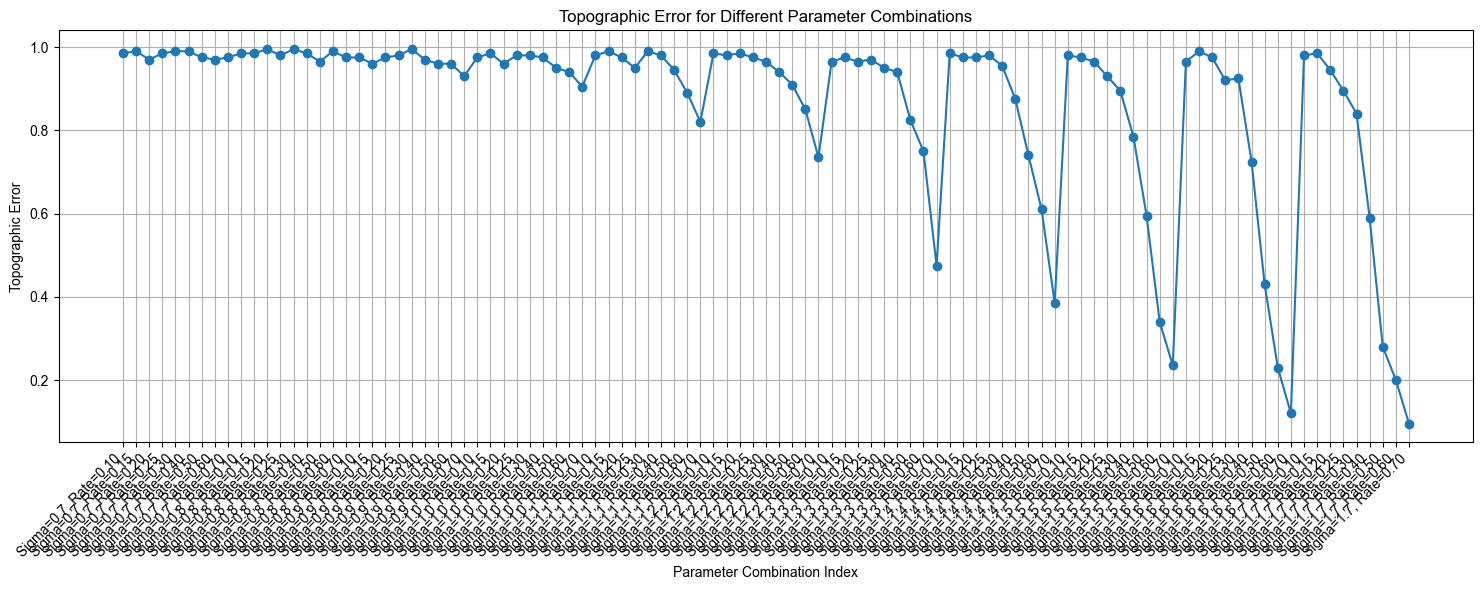

In [8]:
# Plotting to visualise error shifts 

quantization_errors = []
topographic_errors = []
parameter_combinations = []

for (sigma, rate), metrics in results.items():
    parameter_combinations.append((sigma, rate))
    quantization_errors.append(metrics['quant_error'])
    topographic_errors.append(metrics['topo_error'])

# Plotting Quantization Error
plt.figure(figsize=(15, 6))
plt.plot(range(len(quantization_errors)), quantization_errors, marker='o')
plt.xlabel('Parameter Combination Index')
plt.ylabel('Quantization Error')
plt.title('Quantization Error for Different Parameter Combinations')
plt.xticks(range(len(parameter_combinations)), [f'Sigma={s:.1f}, Rate={r:.2f}' for s, r in parameter_combinations], rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting Topographic Error
plt.figure(figsize=(15, 6))
plt.plot(range(len(topographic_errors)), topographic_errors, marker='o')
plt.xlabel('Parameter Combination Index')
plt.ylabel('Topographic Error')
plt.title('Topographic Error for Different Parameter Combinations')
plt.xticks(range(len(parameter_combinations)), [f'Sigma={s:.1f}, Rate={r:.2f}' for s, r in parameter_combinations], rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Training and evaluating map with optimal parameters = sigma and learning rate

In [9]:
# Training of SOM map
# In this demo, a trained SOM object is provided

# som = MiniSom(size, 
#            size, 
#            10, 
#            sigma=1.5, 
#            learning_rate=0.5,
#            topology='rectangular',	
#            neighborhood_function = 'gaussian',
#            activation_distance ='euclidean')
#som.random_weights_init(data_for_som)
#som.train_random(data_for_som, 1000, verbose=True)

In [10]:
# Save SOM model

#with open('som.p', 'wb') as outfile:
#   pickle.dump(som, outfile)

In [11]:
# Load pre-trained SOM model for demo

with open('som.p', 'rb') as infile:
    som = pickle.load(infile)

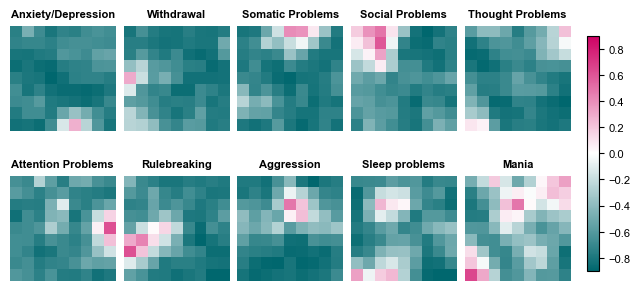

In [12]:
# Visualize trained SOM as whole grid and weight panels

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Custom color mapping
colors = ["#00676E", "#FFFFFF", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

weights = som.get_weights()  


clean_labels = ['Anxiety/Depression', 'Withdrawal', 'Somatic Problems', 'Social Problems', 'Thought Problems', 'Attention Problems', 'Rulebreaking', 'Aggression', 'Sleep problems', 'Mania']

# fixed symmetric range
norm = TwoSlopeNorm(vmin=-0.9, vcenter=0, vmax=0.9)

fig, axes = plt.subplots(2, 5, figsize=(6.3, 3), constrained_layout=True)
axes = axes.ravel()

for i in range(weights.shape[2]):
    im = axes[i].imshow(
        weights[:, :, i],
        cmap=custom_cmap,
        norm=norm
    )
    axes[i].set_title(clean_labels[i], fontsize=8, fontweight='bold')
    axes[i].axis('off')

cbar = fig.colorbar(im, ax=axes, orientation='vertical',
                    fraction=0.021, pad=0.03)
cbar.ax.tick_params(labelsize=8)

plt.show()

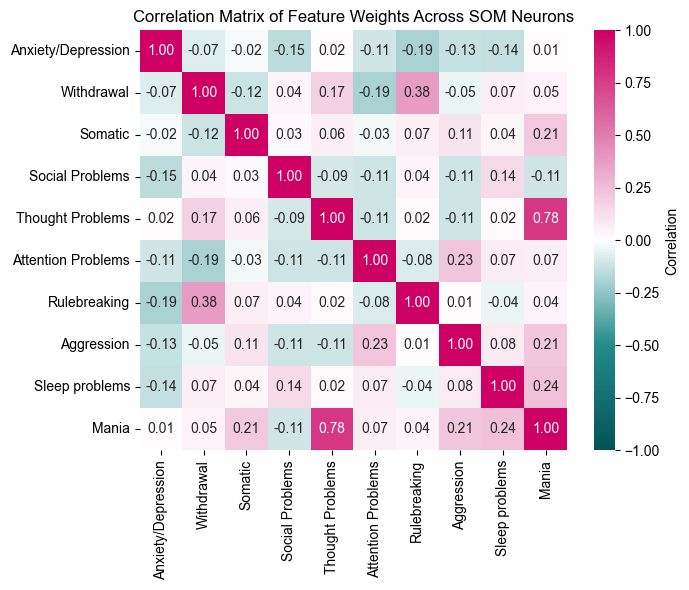

In [13]:
# Obtain correlation matrix of feature weights across SOM neurons to observe correlation between inputted features (symptoms)

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Define model features with custom naming and chosen sigma and learning rate (from chosen SOM model)
feature_names = ['Anxiety/Depression', 'Withdrawal', 'Somatic', 'Social Problems', 'Thought Problems', 'Attention Problems', 'Rulebreaking', 'Aggression', 'Sleep problems', 'Mania']
target_sigma = 1
target_rate = 0.5

weights = som.get_weights()  # Get weights from SOM model

# Obtain number of neurons and features
grid_rows = weights.shape[0]
grid_cols = weights.shape[1]
num_features = weights.shape[2]
num_neurons = grid_rows * grid_cols

# Reshape the weights so that row is a feature and each column is a neuron
reshaped_weights = weights.reshape(grid_rows * grid_cols, num_features).T

# Calculate the correlation matrix between the features across all neurons
correlation_matrix = np.corrcoef(reshaped_weights)

# Custom color mapping
colors = ["#025358","#238B8B", "#FFFFFFFF","#e07eb0", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

# Visualize the correlation matrix
fig = plt.figure(figsize=(7,6))
sns.heatmap(correlation_matrix, annot=True, cmap=custom_cmap, vmin=-1, vmax=1, center=0, # Specify the data range and center
            xticklabels=feature_names,
            yticklabels=feature_names,
            fmt=".2f",
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Feature Weights Across SOM Neurons')
plt.tight_layout()
plt.show()

### Sample statistics - numbers in non-clinical, subclinical and clinical ranges.

In [14]:
# Select all symptom columns (features which went into SOM)
symptom_cols = ['cbcl_scr_syn_anxdep_r', 'cbcl_scr_syn_withdep_r', 'cbcl_scr_syn_somatic_r', 'cbcl_scr_syn_social_r', 'cbcl_scr_syn_thought_r', 'cbcl_scr_syn_attention_r', 'cbcl_scr_syn_rulebreak_r', 'cbcl_scr_syn_aggressive_r', 'sds_p_ss_dims_final', 'Mania_Total']
df_symptoms = mock_baseline[symptom_cols]

perc_95 = df_symptoms.quantile(0.95)
perc_98 = df_symptoms.quantile(0.98)


below_95_all = (df_symptoms <= perc_95).all(axis=1)
percent_below_95_all = (below_95_all.sum() / len(below_95_all)) * 100
print(f"% of participants with all symptoms below 95th percentile: {percent_below_95_all:.2f}%")
print(f"Number of participants with all symptoms below 95th percentile: {below_95_all.sum()}")

above_95_any = (df_symptoms > perc_95).any(axis=1)
percent_above_95_any = (above_95_any.sum() / len(above_95_any)) * 100
print(f"% of participants with any symptom above 95th percentile: {percent_above_95_any:.2f}%")
print(f"Number of participants with any symptom above 95th percentile: {above_95_any.sum()}")

above_98_any = (df_symptoms > perc_98).any(axis=1)
percent_above_98_any = (above_98_any.sum() / len(above_98_any)) * 100
print(f"% of participants with any symptom above 98th percentile: {percent_above_98_any:.2f}%")
print(f"Number of participants with any symptom above 98th percentile: {above_98_any.sum()}")

% of participants with all symptoms below 95th percentile: 63.50%
Number of participants with all symptoms below 95th percentile: 127
% of participants with any symptom above 95th percentile: 36.50%
Number of participants with any symptom above 95th percentile: 73
% of participants with any symptom above 98th percentile: 18.00%
Number of participants with any symptom above 98th percentile: 36


----

## Interpreting SOM Topology

### Testing K-Means clustering on SOM

For n_clusters=2, the silhouette score is: 0.18819606080298876
For n_clusters=3, the silhouette score is: 0.19335882301526877
For n_clusters=4, the silhouette score is: 0.21849666110035385


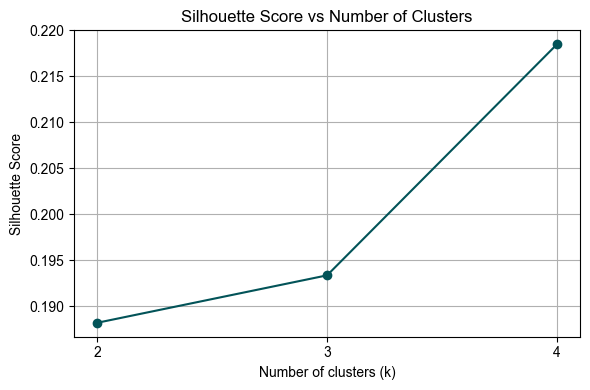

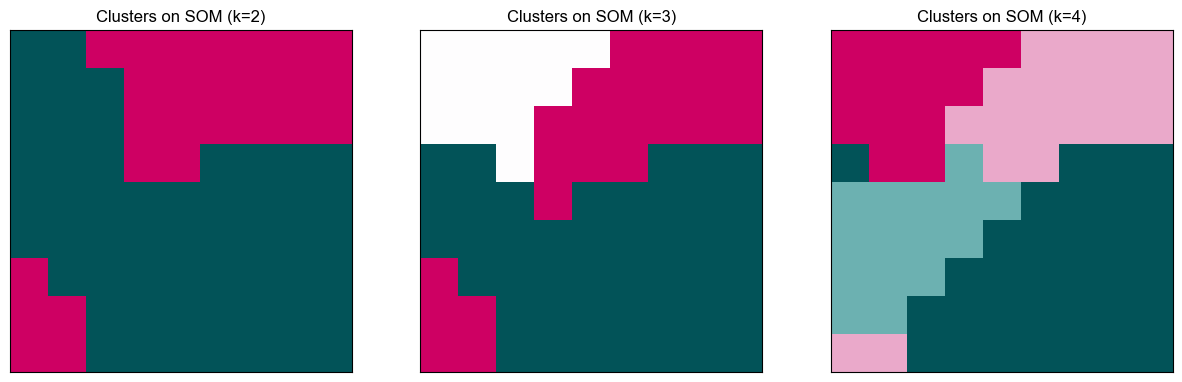

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.colors import LinearSegmentedColormap

colours = ["#025358","#238B8B", "#FFFFFFFF","#e07eb0", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colours)

weights = som.get_weights()
weights_flat = weights.reshape(-1, weights.shape[2]) # flatten the weights to shape (num_neurons, num_features)

cluster_range = range(2, 5) 
silhouette_scores = []
kmeans_models = {}
cluster_labels_reshaped = {}

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42) # Increased n_init for stability
    labels = kmeans.fit_predict(weights_flat)
    silhouette_avg = silhouette_score(weights_flat, labels)
    silhouette_scores.append(silhouette_avg)
    kmeans_models[n_clusters] = kmeans
    cluster_labels_reshaped[n_clusters] = labels.reshape(som.get_weights().shape[0], som.get_weights().shape[1])
    print(f'For n_clusters={n_clusters}, the silhouette score is: {silhouette_avg}')

plt.figure(figsize=(6, 4))
plt.plot(cluster_range, silhouette_scores, marker='o', color= "#025358")
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.xticks(cluster_range)
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualize the cluster solutions for k=2 to 5
num_plots = len(cluster_range)
fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))

for i, k in enumerate(cluster_range):
    ax = axes[i]
    cmap = custom_cmap
    im = ax.imshow(cluster_labels_reshaped[k], cmap=cmap)
    ax.set_title(f'Clusters on SOM (k={k})')
    ax.set_xticks([])
    ax.set_yticks([])



Observed poor separability of clusters with low silhouette scoring, proceeding to alternative method of psychopathology profile testing

### Alternative to clustering - psychopathology profiles

The following code sections provide the construction and testing of psychopathology profiles referenced in the manuscript. The analysis included three steps:
1. Generation of 50 simulated individuals matching each of 8 theory-driven psychopathology profiles, generated by extracting the covariance matrix of the original dataset and manipulating individual feature levels to simulate heightened symptoms (defined as >= 90th percentile in this demo) in profile-specific combinations. 
2. Data from sets of simulated individuals exhibiting a candidate profile were used to train an ensemble tree-based classifier, Random Forrest, which then classifies the weight vectors of SOM neurons into one of 8 profiles or a null (median) profile.
3. After assignment of nodes, permutation testing was used to establish the robustness of identified zones within SOM topology. The neuron weight vectors of the SOM were randomly shuffled 1000 times and the classifier was applied to the shuffled maps, recording the sizes of adjacent (including diagonal) nodes on the map. Observed zones from the original classification were compared to the null distributions and those surpassing a threshold of five contiguous nodes were retained as non-random, statistically robust profile zones.

In [16]:
# requires participant data == data_for_som

# Define number of features (10) to match SOM training and number of sim participants (50)
n_features = 10
n_simulated = 50


# Obtain covariance matrix of original data
cov_original = np.cov(data_for_som.T)

print(cov_original.shape)
print(cov_original)

(10, 10)
[[ 8.45140519e-02 -1.21070778e-03  3.59036915e-03 -7.88524527e-03
   2.90456114e-03 -7.34644374e-03 -7.09571996e-03 -2.16720598e-03
  -1.33708686e-02 -1.45442017e-03]
 [-1.21070778e-03  1.02241541e-01 -2.65854395e-03 -4.09363066e-03
   9.43022031e-03 -9.76649522e-03  1.88540406e-02  2.52912965e-03
   2.23320141e-03  1.05668291e-02]
 [ 3.59036915e-03 -2.65854395e-03  1.08724800e-01  3.13366659e-04
  -6.74044201e-04  2.70339978e-04  9.97048510e-03  6.44478062e-03
  -8.91848976e-04  9.44724195e-03]
 [-7.88524527e-03 -4.09363066e-03  3.13366659e-04  1.49172337e-01
  -1.74461166e-03 -8.57625709e-03  3.84222345e-03 -7.02234880e-03
   7.43114302e-03 -1.78917133e-02]
 [ 2.90456114e-03  9.43022031e-03 -6.74044201e-04 -1.74461166e-03
   1.01588396e-01 -1.09085166e-02  1.06143955e-04 -3.29008131e-03
  -5.61828966e-03  8.04759430e-02]
 [-7.34644374e-03 -9.76649522e-03  2.70339978e-04 -8.57625709e-03
  -1.09085166e-02  1.41215573e-01 -3.51493385e-03  1.60695303e-02
   1.16482965e-02  7.343

In [17]:
# Define profile parameter cutoff - 90th percentile in demo
percentile_cutoff = 90

# Creating High Psychopathology profile - above 90th percentile on all features
high_archetype = np.percentile(data_for_som, percentile_cutoff, axis=0)
print(f"High Psychopathology profile defined by {percentile_cutoff}th percentile per feature: {high_archetype}")

High Psychopathology profile defined by 90th percentile per feature: [-0.40563985 -0.31596215 -0.20855166 -0.03404419 -0.27051796 -0.07226072
 -0.12165783 -0.19170101 -0.11528964  0.19563785]


In [18]:
# Generate data points centered around the defined profile, but preserving the original covariance structure

seed_value = 42
rng = np.random.default_rng(seed=seed_value) # Random number generator for reproducibility

simulated_high_scores = rng.multivariate_normal(high_archetype, cov_original, size=n_simulated) 
print(f"Generated simulated data shape: {simulated_high_scores.shape}")

print(simulated_high_scores[:5]) # Inspect first 5 simulated data points

# Clamp the simulated data to same range as the original data (minmax scaled (-1,1)
scale_min = -1.0
scale_max =  1.0

simulated_high_scores = np.clip(simulated_high_scores, scale_min, scale_max)

Generated simulated data shape: (50, 10)
[[-0.34276706 -0.21426935 -0.75460059 -0.39410363 -0.32271705 -0.68275696
  -0.22410949 -0.75409817 -0.19341442  0.14963473]
 [-0.69231862 -0.77914826 -0.51912778  0.16842001 -0.35944824  0.01402826
  -0.5849541  -0.34799971 -0.1611243  -0.04323646]
 [-0.37626818 -0.2375398  -0.17709608 -0.4702356  -0.07388394 -0.17788736
  -0.1163281  -0.44281052 -0.4618715   0.19782727]
 [-0.22488809 -0.62135558 -0.01867558  0.30794503 -0.7780793  -0.17573996
   0.16936526  0.05139376 -0.27504617 -0.74579426]
 [-0.6005359  -0.49204612 -0.00659043  0.18132447 -0.44213877  0.05210504
  -0.27755424 -0.41081149  0.07866804 -0.08600474]]


50 BMUs for High Psychopathology Found


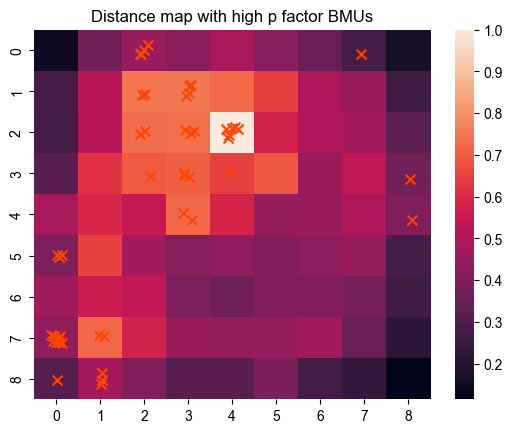

In [19]:
# Inspect best matching units (BMUs) for participants in simulated high scores (High Psychopathology) profile

# Obtain BMUs as np array
bmus_high_scores = []
for sample in simulated_high_scores:
    bmu = som.winner(sample)
    bmus_high_scores.append(bmu)

bmus_high_scores = np.array(bmus_high_scores)

# Count the number of BMUs found (expected 500)
print(f"{len(bmus_high_scores)} BMUs for High Psychopathology Found")

# Visualize for simulated high scores profile
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_high_scores[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_high_scores[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='orangered', s=50, label='High Scores Archetype BMUs', marker='x')
plt.title('Distance map with high p factor BMUs')
plt.show()

In [20]:
# Using 90th percentile cutoff as hightened symptoms and 50th to define median of sample
high_values = np.percentile(data_for_som, percentile_cutoff, axis=0)
median_values = np.percentile(data_for_som, 50, axis=0)

In [21]:
# Select which features to elevate within each profile

internalising_features_indices = [0, 1, 2] # anxiety/depression, withdrawal, somatic problems
externalizing_features_indices = [6, 7]    # aggression and rule-breaking
somaticizing_features_indices = [2, 8] # somatic and sleep problems
mania_features_indices = [4, 9] # thought and mania
mood_features_indices = [0, 1, 2, 4, 8, 9] # depression/anxiety, withdrawn, somatic, thought, sleep and mania 
cognitive_features_indices = [4, 5]   # thought and attention problems
withdrawnsocialprob_features_indices = [1, 3]   # withdrawn and social problems


 Mean Vector for Internalising Archetype:
[-0.40563985 -0.31596215 -0.20855166 -0.69354958 -0.71742036 -0.69014732
 -0.7456202  -0.73557855 -0.63632648 -0.43615016]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated 'Internalising' archetype.
Inspecting first 10 BMUs: [[8 3]
 [0 7]
 [0 6]
 [8 5]
 [7 0]
 [8 4]
 [1 5]
 [7 1]
 [1 5]
 [4 0]]


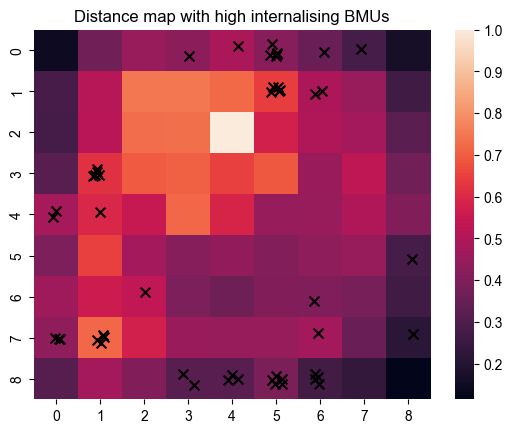

In [22]:
# Create simulated internalising profile

# Start with median values as baseline
internalising_archetype = median_values.copy()

# Set specified features to their 'high' percentile value
for index in internalising_features_indices:
    internalising_archetype[index] = high_values[index]

print(f"\n Mean Vector for Internalising Archetype:\n{internalising_archetype}")

# Simulate internalising profile data using the specified internalising values for high, with original data covariance
simulated_internalising = rng.multivariate_normal(internalising_archetype,
                                                      cov_original,
                                                      size=n_simulated)

print(f"Generated simulated data shape: {simulated_internalising.shape}")
simulated_internalising = np.clip(simulated_internalising, scale_min, scale_max)

# Find BMUs for the simulated internalising scores

bmus_internalising = []
for sample in simulated_internalising:
    bmu = som.winner(sample) 
    bmus_internalising.append(bmu)

bmus_internalising = np.array(bmus_internalising)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 500
print(f"Found {len(bmus_internalising)} BMUs for the simulated 'Internalising' archetype.")
print("Inspecting first 10 BMUs:", bmus_internalising[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_internalising[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_internalising[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='black', s=50, label='High Scores Archetype BMUs', marker='x')
plt.title('Distance map with high internalising BMUs')
plt.show()


 Mean Vector for Internalizing Archetype:
[-0.78073357 -0.77602699 -0.75747649 -0.69354958 -0.71742036 -0.69014732
 -0.12165783 -0.19170101 -0.63632648 -0.43615016]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated 'Externalising' archetype.
Inspecting first 10 BMUs: [[5 3]
 [4 3]
 [3 6]
 [6 3]
 [3 4]
 [1 6]
 [3 6]
 [5 0]
 [3 5]
 [1 5]]


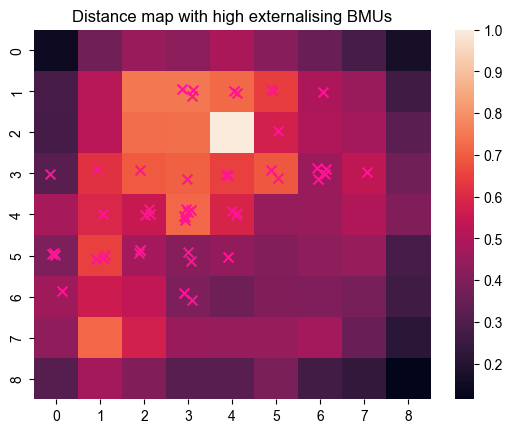

In [23]:
# Create simulated externalizing profile

# Start with median values as baseline
externalising_archetype = median_values.copy()

# Set specified features to their 'high' percentile value
for index in externalizing_features_indices:
    externalising_archetype[index] = high_values[index]

print(f"\n Mean Vector for Internalizing Archetype:\n{externalising_archetype}")

simulated_externalising = rng.multivariate_normal(externalising_archetype,
                                                      cov_original,               
                                                      size=n_simulated)

print(f"Generated simulated data shape: {simulated_externalising.shape}")
simulated_externalising = np.clip(simulated_externalising, scale_min, scale_max)

# Find BMUs for the simulated externalising scores
bmus_externalising = []
for sample in simulated_externalising:
    bmu = som.winner(sample) 
    bmus_externalising.append(bmu)

bmus_externalising = np.array(bmus_externalising)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 500
print(f"Found {len(bmus_externalising)} BMUs for the simulated 'Externalising' archetype.")
print("Inspecting first 10 BMUs:", bmus_externalising[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_externalising[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_externalising[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='deeppink', s=50, label='High Scores Archetype BMUs', marker='x')
plt.title('Distance map with high externalising BMUs')
plt.show()


 Mean Vector for somaticizing Archetype:
[-0.78073357 -0.77602699 -0.20855166 -0.69354958 -0.71742036 -0.69014732
 -0.7456202  -0.73557855 -0.11528964 -0.43615016]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated 'somaticizing' archetype.
Inspecting first 10 BMUs: [[1 5]
 [8 3]
 [7 1]
 [3 8]
 [3 6]
 [7 0]
 [8 2]
 [8 4]
 [3 1]
 [7 0]]


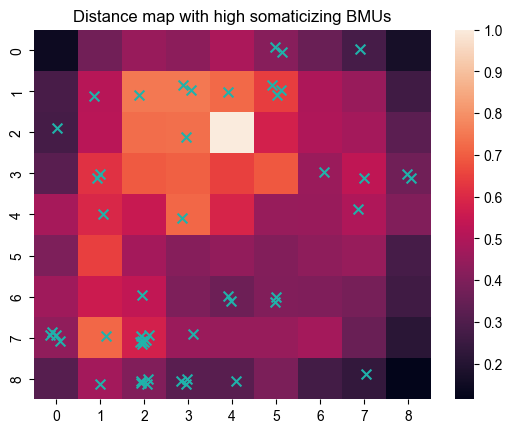

In [24]:
# Create simulated somaticising profile

# Start with median values as baseline
somaticising_archetype = median_values.copy()

# Set specified features to their 'high' percentile value
for index in somaticizing_features_indices:
    somaticising_archetype[index] = high_values[index]

print(f"\n Mean Vector for somaticizing Archetype:\n{somaticising_archetype}")

simulated_somaticising = rng.multivariate_normal(somaticising_archetype,
                                                      cov_original,          
                                                      size=n_simulated)

print(f"Generated simulated data shape: {simulated_somaticising.shape}")
simulated_somaticising = np.clip(simulated_somaticising, scale_min, scale_max)

# Finding best matching units (BMUs) for the simulated Internalizing scores

bmus_somaticising = []
for sample in simulated_somaticising:
    bmu = som.winner(sample) 
    bmus_somaticising.append(bmu)

# Convert list of tuples to a NumPy array
bmus_somaticising = np.array(bmus_somaticising)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 100
print(f"Found {len(bmus_somaticising)} BMUs for the simulated 'somaticizing' archetype.")
print("Inspecting first 10 BMUs:", bmus_somaticising[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map and weights map


sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_somaticising[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_somaticising[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='lightseagreen', s=50, label='High Scores Archetype BMUs', marker='x')
plt.title('Distance map with high somaticizing BMUs')
plt.show()


 Mean Vector for mania Archetype:
[-0.78073357 -0.77602699 -0.75747649 -0.69354958 -0.27051796 -0.69014732
 -0.7456202  -0.73557855 -0.63632648  0.19563785]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated mania archetype.
Inspecting first 10 BMUs: [[1 7]
 [0 8]
 [1 7]
 [8 6]
 [6 6]
 [1 7]
 [0 8]
 [7 1]
 [1 3]
 [1 7]]


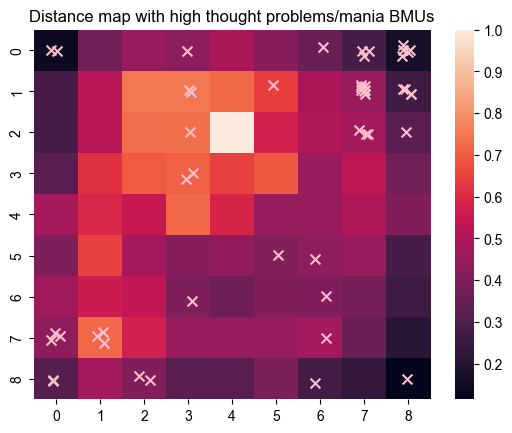

In [25]:
# Create simulated mania profile

# Start with median values as baseline
mania_archetype = median_values.copy()

# Set specified features to their 'high' percentile value
for index in mania_features_indices:
    mania_archetype[index] = high_values[index]

print(f"\n Mean Vector for mania Archetype:\n{mania_archetype}")

simulated_mania = rng.multivariate_normal(mania_archetype, 
                                                      cov_original,                
                                                      size=n_simulated)

print(f"Generated simulated data shape: {simulated_mania.shape}") # (expected 500, 10)
simulated_mania = np.clip(simulated_mania, scale_min, scale_max)

# Find BMUs for the simulated mania scores
bmus_mania = []
for sample in simulated_mania:
    bmu = som.winner(sample) 
    bmus_mania.append(bmu)

bmus_mania = np.array(bmus_mania)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 500
print(f"Found {len(bmus_mania)} BMUs for the simulated mania archetype.")
print("Inspecting first 10 BMUs:", bmus_mania[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_mania[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_mania[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='pink', s=50, label='High Scores Archetype BMUs', marker='x')
plt.title('Distance map with high thought problems/mania BMUs')
plt.show()


 Vector for broad mood-type Archetype:
[-0.40563985 -0.31596215 -0.20855166 -0.69354958 -0.27051796 -0.69014732
 -0.7456202  -0.73557855 -0.11528964  0.19563785]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated mood-type archetype.
Inspecting first 10 BMUs: [[0 6]
 [8 0]
 [2 4]
 [1 4]
 [8 1]
 [7 0]
 [2 8]
 [4 6]
 [8 0]
 [8 0]]


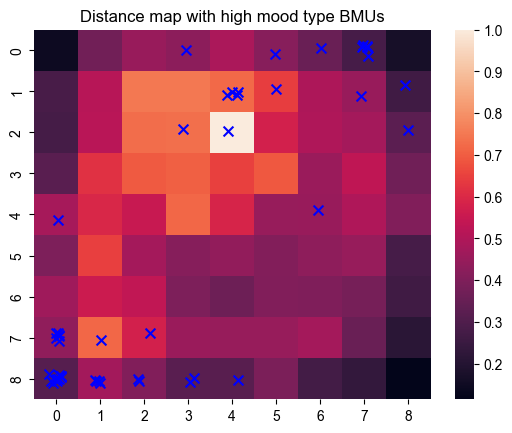

In [26]:
# Create simulated mood profile

# Start with median values as baseline
mood_archetype = median_values.copy()

# Set specified features to their 'high' percentile value
for index in mood_features_indices:
    mood_archetype[index] = high_values[index]

print(f"\n Vector for broad mood-type Archetype:\n{mood_archetype}")

simulated_mood = rng.multivariate_normal(mood_archetype,
                                                    cov_original,              
                                                    size=n_simulated)

print(f"Generated simulated data shape: {simulated_mood.shape}") # (expected 500, 10)
simulated_mood = np.clip(simulated_mood, scale_min, scale_max)

# Find BMUs for the simulated mood scores
bmus_mood = []
for sample in simulated_mood:
    bmu = som.winner(sample) 
    bmus_mood.append(bmu)

bmus_mood = np.array(bmus_mood)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 500
print(f"Found {len(bmus_mood)} BMUs for the simulated mood-type archetype.")
print("Inspecting first 10 BMUs:", bmus_mood[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_mood[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
            bmus_mood[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
            c='blue', s=50, label='High mood type Archetype BMUs', marker='x')
plt.title('Distance map with high mood type BMUs')
plt.show()


 Mean Vector for cognitive (thought/attention) Archetype:
[-0.78073357 -0.77602699 -0.75747649 -0.69354958 -0.27051796 -0.07226072
 -0.7456202  -0.73557855 -0.63632648 -0.43615016]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated cognitive archetype.
Inspecting first 10 BMUs: [[5 8]
 [1 0]
 [3 8]
 [4 7]
 [5 8]
 [5 4]
 [5 7]
 [0 0]
 [4 4]
 [5 8]]


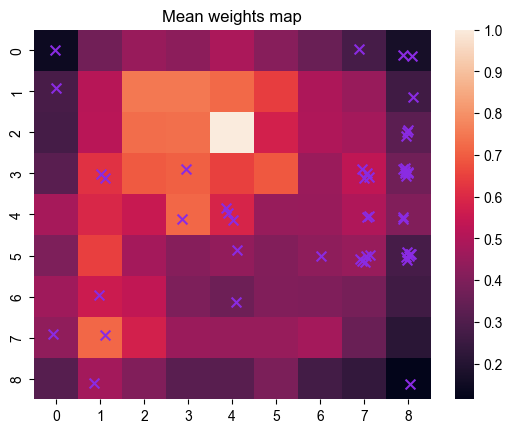

In [27]:
# Create simulated cognitive profile

# Start with median values as baseline
cognitive_archetype = median_values.copy()

# Set specified features to their 'high' percentile value
for index in cognitive_features_indices:
    cognitive_archetype[index] = high_values[index]

print(f"\n Mean Vector for cognitive (thought/attention) Archetype:\n{cognitive_archetype}")

simulated_cognitive = rng.multivariate_normal(cognitive_archetype,
                                                      cov_original,              
                                                      size=n_simulated)

print(f"Generated simulated data shape: {simulated_cognitive.shape}") # (expected 500, 10)
simulated_cognitive = np.clip(simulated_cognitive, scale_min, scale_max)

# Find BMUs for the simulated cognitive scores
bmus_cognitive = []
for sample in simulated_cognitive:
    bmu = som.winner(sample) 
    bmus_cognitive.append(bmu)

bmus_cognitive = np.array(bmus_cognitive)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 500
print(f"Found {len(bmus_cognitive)} BMUs for the simulated cognitive archetype.")
print("Inspecting first 10 BMUs:", bmus_cognitive[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_cognitive[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_cognitive[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='blueviolet', s=50, label='High Scores Archetype BMUs', marker='x')
plt.title('Mean weights map')
plt.show()


 Mean Vector for Withdrawn/social problems Archetype:
[-0.78073357 -0.31596215 -0.75747649 -0.03404419 -0.71742036 -0.69014732
 -0.7456202  -0.73557855 -0.63632648 -0.43615016]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated 'Withdrawn/social problems' archetype.
Inspecting first 10 BMUs: [[3 1]
 [1 1]
 [4 2]
 [2 0]
 [1 1]
 [4 1]
 [1 2]
 [6 7]
 [3 1]
 [3 6]]


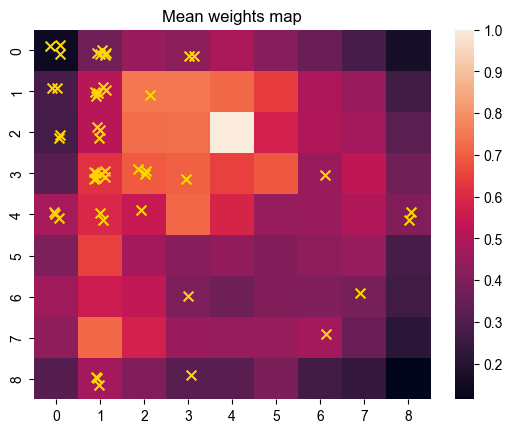

In [28]:
# Create simulated social problems profile

# Start with median values as baseline
withdrawnsocialprob_archetype = median_values.copy()

# Set specified features to their 'high' percentile value
for index in withdrawnsocialprob_features_indices:
    withdrawnsocialprob_archetype[index] = high_values[index]

print(f"\n Mean Vector for Withdrawn/social problems Archetype:\n{withdrawnsocialprob_archetype}")

simulated_withdrawnsocialprob = rng.multivariate_normal(withdrawnsocialprob_archetype, 
                                                      cov_original,             
                                                      size=n_simulated)

print(f"Generated simulated data shape: {simulated_withdrawnsocialprob.shape}") # (expected 500, 10)
simulated_withdrawnsocialprob = np.clip(simulated_withdrawnsocialprob, scale_min, scale_max)

# Find BMUs for the simulated social problems scores
bmus_withdrawnsocialprob = []
for sample in simulated_withdrawnsocialprob:
    bmu = som.winner(sample) 
    bmus_withdrawnsocialprob.append(bmu)

bmus_withdrawnsocialprob = np.array(bmus_withdrawnsocialprob)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 500
print(f"Found {len(bmus_withdrawnsocialprob)} BMUs for the simulated 'Withdrawn/social problems' archetype.")
print("Inspecting first 10 BMUs:", bmus_withdrawnsocialprob[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_withdrawnsocialprob[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_withdrawnsocialprob[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='gold', s=50, label='High Scores Archetype BMUs', marker='x')
plt.title('Mean weights map')
plt.show()


 Vector for Low Problems (Median) Archetype:
[-0.78073357 -0.77602699 -0.75747649 -0.69354958 -0.71742036 -0.69014732
 -0.7456202  -0.73557855 -0.63632648 -0.43615016]
Generated simulated data shape: (50, 10)
Found 50 BMUs for the simulated 'No problems' archetype.
Inspecting first 10 BMUs: [[4 5]
 [7 7]
 [5 3]
 [0 7]
 [5 3]
 [7 8]
 [4 6]
 [5 6]
 [4 6]
 [7 8]]


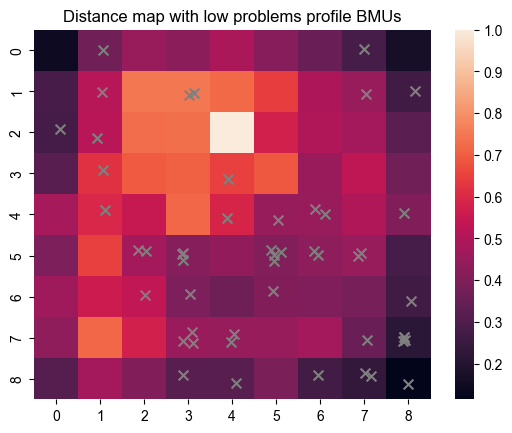

In [29]:
# Create simulated mania profile

# Start with median values as baseline
noproblems_archetype = median_values.copy()
print(f"\n Vector for Low Problems (Median) Archetype:\n{noproblems_archetype}")

simulated_noproblems = rng.multivariate_normal(noproblems_archetype,
                                                      cov_original,           
                                                      size=n_simulated)

print(f"Generated simulated data shape: {simulated_noproblems.shape}")  # (expected 500, 10)
simulated_noproblems = np.clip(simulated_noproblems, scale_min, scale_max)

# Find BMUs for the simulated no problem scores
bmus_noproblems = []
for sample in simulated_noproblems:
    bmu = som.winner(sample) 
    bmus_noproblems.append(bmu)

bmus_noproblems = np.array(bmus_noproblems)

# Count the number of BMUs found for the simulated high scores to see if it matches expected 500
print(f"Found {len(bmus_noproblems)} BMUs for the simulated 'No problems' archetype.")
print("Inspecting first 10 BMUs:", bmus_noproblems[:10])

# Visualize the BMUs for the simulated high scores on the SOM distance map
sns.heatmap(som.distance_map()) 
jitter = 0.3
plt.scatter(bmus_noproblems[:, 1] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter, # there is a transposition here where the som outputs width x height and the scatter expects height x width. This either requires sns.heatmap(som.distance_map().T) OR reversing the dimensions of the scatter plot. 
             bmus_noproblems[:, 0] + 0.5 + (np.random.rand(n_simulated) - 0.5) * jitter,
             c='grey', s=50, label='Low problems Archetype BMUs', marker='x')
plt.title('Distance map with low problems profile BMUs')
plt.show()

----

## Classifier

In [30]:
simulated_archetypes_data_dict = {
    'simulated_high_scores': simulated_high_scores,  
    'simulated_internalising': simulated_internalising,
    'simulated_externalising': simulated_externalising,
    'simulated_somaticising': simulated_somaticising,
    'simulated_mania': simulated_mania,
    'simulated_mood': simulated_mood,
    'simulated_cognitive': simulated_cognitive,
    'simulated_withdrawnsocialprob': simulated_withdrawnsocialprob,
    'simulated_noproblems' : simulated_noproblems
}

X train shape: (450, 10), Y train shape: (450,)
Reshaped SOM weights to shape: (81, 10)


C:\Users\mj03\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\mj03\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


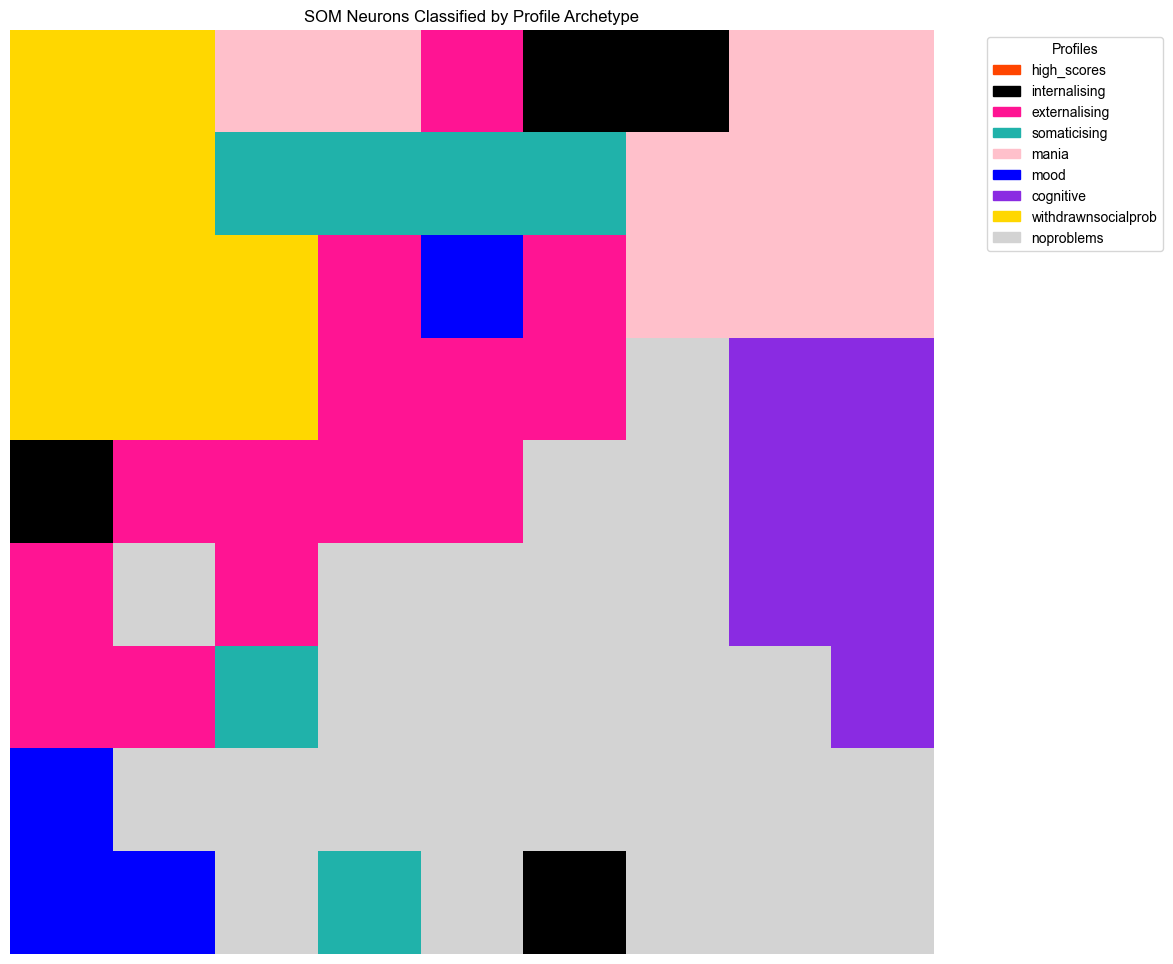

In [31]:
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import joblib

# Assign fixed order of profiles for classifier
ordered_profiles = [
    'simulated_high_scores',
    'simulated_internalising',
    'simulated_externalising',
    'simulated_somaticising',
    'simulated_mania',
    'simulated_mood',
    'simulated_cognitive',
    'simulated_withdrawnsocialprob',
    'simulated_noproblems'
]

# Combine X and Y training data from simulated profile to match to profile label
X_train_list = []
Y_train_list = []

for profile_name in ordered_profiles:
    if profile_name in simulated_archetypes_data_dict:
        data = simulated_archetypes_data_dict[profile_name]
        X_train_list.append(data) 
        Y_train_list.append([profile_name] * len(data))

X_train = np.vstack(X_train_list)
Y_train = np.concatenate(Y_train_list)

print(f"X train shape: {X_train.shape}, Y train shape: {Y_train.shape}")

# Obtain SOM weights
som_weights = som.get_weights()
map_dims = som_weights.shape[:2]
X_to_predict = som_weights.reshape(-1, som_weights.shape[2]) 
print(f"Reshaped SOM weights to shape: {X_to_predict.shape}")

# Train classifier - trained classifier is provided for demo
#classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
#classifier.fit(X_train, Y_train)

classifier = joblib.load("profile_classifier.pkl")
neuron_labels = classifier.predict(X_to_predict)

# Visualise spread of profiles on SOM
archetype_specific_colors = {
    'simulated_high_scores': 'orangered',
    'simulated_internalising': 'black',
    'simulated_externalising': 'deeppink',
    'simulated_somaticising': 'lightseagreen',
    'simulated_mania': 'pink',
    'simulated_mood': 'blue',
    'simulated_cognitive': 'blueviolet',
    'simulated_withdrawnsocialprob': 'gold',
    'simulated_noproblems': 'lightgrey'
}

# Map colors to profile order
color_list = [archetype_specific_colors[name] for name in ordered_profiles]
custom_cmap = ListedColormap(color_list)

# Map text labels to fixed integer indices
label_to_int = {label: i for i, label in enumerate(ordered_profiles)}
numeric_map = np.array([label_to_int[label] for label in neuron_labels]).reshape(map_dims)

# Initiate figure
plt.figure(figsize=(12, 12))
im = plt.imshow(
    numeric_map, cmap=custom_cmap, vmin=0, vmax=len(ordered_profiles) - 1)

# Create legend using the fixed order to match colormap indices
patches = [
    mpatches.Patch(color=color_list[i], label=name.replace('simulated_', '')) 
    for i, name in enumerate(ordered_profiles)
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title='Profiles')

plt.title('SOM Neurons Classified by Profile Archetype')
plt.axis('off')
plt.show()

This code generates a null distribution of island sizes to determine how large a psychopathology profile's zone has to be to be considered a meaningful zone of map topology.

Observed island sizes for each profile:
  - cognitive: [7]
  - externalising: [13, 1]
  - internalising: [2, 1, 1]
  - mania: [8, 2]
  - mood: [3, 1]
  - noproblems: [25, 1]
  - somaticising: [4, 1, 1]
  - withdrawnsocialprob: [10]
Progress of permutations 100/1000...
Progress of permutations 200/1000...
Progress of permutations 300/1000...
Progress of permutations 400/1000...
Progress of permutations 500/1000...
Progress of permutations 600/1000...
Progress of permutations 700/1000...
Progress of permutations 800/1000...
Progress of permutations 900/1000...
Progress of permutations 1000/1000...


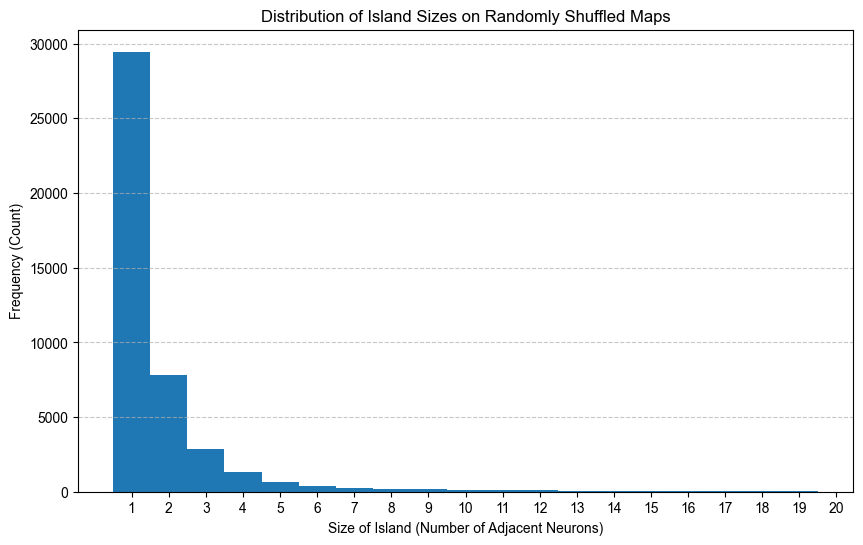

In [32]:
from scipy.ndimage import label

# Get true classification
true_class_order = classifier.classes_
label_to_int = {label: i for i, label in enumerate(true_class_order)}
real_labels_flat = classifier.predict(X_to_predict)
numeric_map = np.array([label_to_int[label] for label in real_labels_flat]).reshape(map_dims)

# Pull observed island sizes from the classifier
observed_island_sizes = {name: [] for name in true_class_order}
connectivity_structure = np.ones((3, 3)) 

for profile_name in true_class_order:
    profile_index = label_to_int[profile_name]
    binary_map = (numeric_map == profile_index)
    labeled_map, num_islands = label(binary_map, structure=connectivity_structure)
    if num_islands > 0:
        island_labels, sizes = np.unique(labeled_map, return_counts=True)
        actual_sizes = sizes[island_labels != 0]
        observed_island_sizes[profile_name].extend(actual_sizes)

# Inspect island sizes
print("Observed island sizes for each profile:")
for name, sizes in observed_island_sizes.items():
    if sizes:
        clean_sizes = [int(s) for s in sorted(sizes, reverse=True)]
        print(f"  - {name.replace('simulated_', '')}: {clean_sizes}")


# Permutation loop to build null distribution of island sizes
n_permutations = 1000
null_distribution_of_island_sizes = []

for i in range(n_permutations):
    if (i + 1) % 100 == 0:
        print(f"Progress of permutations {i+1}/{n_permutations}...")
        
    shuffled_indices = np.random.permutation(X_to_predict.shape[0])
    shuffled_weights = X_to_predict[shuffled_indices]
    
    shuffled_labels_flat = classifier.predict(shuffled_weights)
    shuffled_numeric_map = np.array([label_to_int[label] for label in shuffled_labels_flat]).reshape(map_dims)
    
    for profile_name in true_class_order:
        profile_index = label_to_int[profile_name]
        binary_map = (shuffled_numeric_map == profile_index)
        labeled_map, num_islands = label(binary_map, structure=connectivity_structure)
        if num_islands > 0:
            island_labels, sizes = np.unique(labeled_map, return_counts=True)
            actual_sizes = sizes[island_labels != 0]
            null_distribution_of_island_sizes.extend(actual_sizes)

# Inspect null distribution of island size frequencies
plt.figure(figsize=(10, 6))
plt.hist(null_distribution_of_island_sizes, bins=np.arange(1, 21)-0.5)
plt.title('Distribution of Island Sizes on Randomly Shuffled Maps')
plt.xlabel('Size of Island (Number of Adjacent Neurons)')
plt.ylabel('Frequency (Count)')
plt.xticks(np.arange(1, 21))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [33]:
# Use null distribution from prior step to establish significance cut-off

# Convert list to np array
null_dist_array = np.array(null_distribution_of_island_sizes)

# Calculate the cut-off at 99th percentile and round to even number as island size must be an integer
critical_size = np.percentile(null_dist_array, 99)
critical_size_cutoff = int(np.ceil(critical_size))
print(f"The 99th percentile of the null distribution is: {critical_size:.2f}")
print(f"Minimum significant island size (p < 0.01) is: {critical_size_cutoff} neurons")

# Print significant psychopathology profiles (larger than threshold value)
print("\n Significant Profiles")
for profile_name, sizes in observed_island_sizes.items():
    significant_islands = [s for s in sizes if s >= critical_size_cutoff]
    
    if significant_islands:
        clean_name = profile_name.replace('simulated_', '')
        print(f"  - Profile: {clean_name}")

The 99th percentile of the null distribution is: 13.00
Minimum significant island size (p < 0.01) is: 13 neurons

 Significant Profiles
  - Profile: externalising
  - Profile: noproblems


----

## Overlap with KSADS diagnosis

This analysis plots the number of KSADS-based current diagnoses by matching them to each participant, obtaining their BMU, and plotting number of diagnoses per BMU on SOM. This serves as an external validation of the SOM, to see if the diagnostic and symptom data converge on shared areas of the map topology.

In [34]:
# Load CSV file with diagnosis mock - showing one column of any current diagnosis
mock_diagnosis = pd.read_csv('mock_diagnosis.csv')
print(mock_diagnosis.shape) # expected (200,2)

(200, 2)


In [35]:
# Obtain participant IDs
participant_ids_for_som = mock_baseline['Participant_ID'].values

# Calculate BMUs from trained SOM
all_participant_bmus = np.array([som.winner(sample) for sample in data_for_som])

# Create a new dataframe linking participant IDs to their BMU coordinates
bmu_df = pd.DataFrame({
    'Participant_ID': participant_ids_for_som,
    'bmu_y': all_participant_bmus[:, 0],
    'bmu_x': all_participant_bmus[:, 1]
})

# Merge datasets, keeping only participants who have KSADS data
analysis_df = pd.merge(bmu_df, mock_diagnosis, on='Participant_ID', how='inner')
print(f"Final aligned dataset has {len(analysis_df)} participants.")

Final aligned dataset has 200 participants.


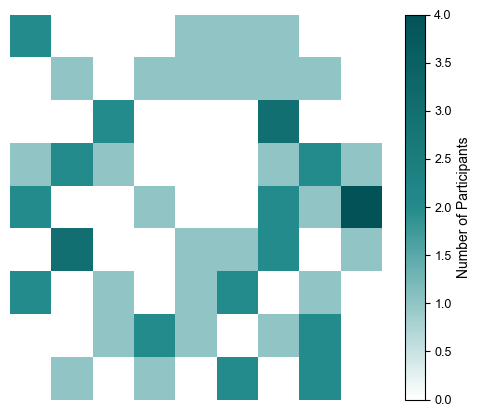

In [36]:
# Define color mapping
colors_abs = [ '#ffffff', "#238B8B", "#025358"]
custom_abs_map = LinearSegmentedColormap.from_list("customabs_cmap", colors_abs)

# Visualise current diagnostic burden
diagnosed_bmus = analysis_df[analysis_df['any_current_diag'] == 1][['bmu_y', 'bmu_x']].values
map_dims = som.get_weights().shape[:2]

plt.figure(figsize=(6, 5))
h = plt.hist2d(
    diagnosed_bmus[:, 1],  # x
    diagnosed_bmus[:, 0],  # y
    bins=map_dims,
    cmap=custom_abs_map
)

plt.gca().invert_yaxis()
cbar = plt.colorbar(label='Number of Participants')
cbar.ax.tick_params(labelsize=9) 
plt.title('')
plt.axis('off')
plt.show()

----

## Saving profile centroid and SOM membership data for next analyses

In [37]:
from scipy import ndimage
import json

# Initialise mapping using classifier assignment
profile_names = classifier.classes_
int_to_label = {i: label for i, label in enumerate(profile_names)}
size_threshold = 13 # from null distribution calculation
significant_islands_report = {}

# Identify significant 'islands' across profiles
unique_profiles = np.unique(numeric_map)

for profile_id in unique_profiles:
    if profile_id not in int_to_label:
        continue

    profile_name = int_to_label[profile_id]
    binary_map = (numeric_map == profile_id)
    
    # Define connectivity (ones(3,3) include diagonals as adjacent)
    structure = np.ones((3, 3))
    labeled_map, num_islands = ndimage.label(binary_map, structure=structure)
    
    for island_label in range(1, num_islands + 1):
        island_mask = (labeled_map == island_label)
        if island_mask.sum() >= size_threshold:
            # Store coordinates as a list of [row, col]
            coords = np.argwhere(island_mask).tolist()
            
            if profile_name not in significant_islands_report:
                significant_islands_report[profile_name] = []
            significant_islands_report[profile_name].append(coords)


# Inspect summary and save file
for profile, islands in significant_islands_report.items():
    clean_name = profile.replace('simulated_', '')
    print(f"\nProfile: {clean_name}")
    for i, island in enumerate(islands):
        print(f"  - Island {i+1}: {len(island)} neurons.")

#with open('significant_islands_report_mock.json', 'w') as f:
#    json.dump(significant_islands_report, f, indent=4)

print("\nReport saved to 'significant_islands_report_mock.json'")


Profile: externalising
  - Island 1: 13 neurons.

Profile: noproblems
  - Island 1: 25 neurons.

Report saved to 'significant_islands_report_mock.json'


In [38]:
from scipy.ndimage import label

# Code chunk assumes 'bmu_df', 'numeric_map', 'label_to_int', and 'true_class_order' defined in prior parts of script
significant_islands_info = []
connectivity_structure = np.ones((3,3))

# Identify spatially significant clusters
for profile_name in true_class_order:
    profile_index = label_to_int[profile_name]
    binary_map = (numeric_map == profile_index)
    labeled_map, num_islands = label(binary_map, structure=connectivity_structure)
    
    if num_islands == 0: continue
        
    island_ids, island_sizes = np.unique(labeled_map, return_counts=True)
    
    # Filter for islands meeting the minimum neuron size threshold (5)
    island_counter = 1
    for island_id, size in zip(island_ids, island_sizes):
        if island_id == 0 or size < critical_size_cutoff:
            continue
            
        island_coords = np.argwhere(labeled_map == island_id)
        significant_islands_info.append({
            'island_name': f"{profile_name.replace('simulated_', '')}_{island_counter}",
            'coords_set': set(map(tuple, island_coords))
        })
        island_counter += 1

# Build binary participant membership matrix for the identified islands
membership_df = pd.DataFrame(index=bmu_df['Participant_ID'])
participant_bmus = bmu_df[['bmu_y', 'bmu_x']].apply(tuple, axis=1)
participant_bmus.index = bmu_df['Participant_ID']

for island in significant_islands_info:
    # Assign 1 if a participant's BMU coordinates fall within this island's set
    membership_df[island['island_name']] = participant_bmus.isin(island['coords_set']).astype(int)

# Export finalized matrices for PLS analysis
#membership_df.to_csv('som_island_membership.csv')
print(f"Saved 'som_island_membership.csv' with shape {membership_df.shape}")


Saved 'som_island_membership.csv' with shape (200, 2)
